Simple for loop implementation for Mandelbrot

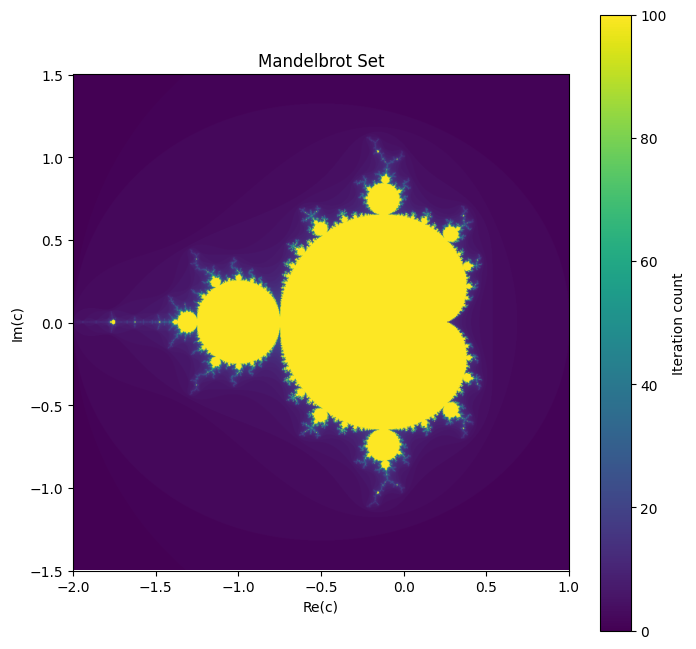

7.55 s ± 409 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define region: 𝑥 ∈ [−2,1],  𝑦 ∈[−1.5,1.5]
# Typical: 𝑚𝑎𝑥_𝑖𝑡𝑒𝑟 =100, resolution: 1024×1024 or large
xmin, xmax = -2, 1
ymin, ymax = -1.5, 1.5
width, height = 1024, 1024
max_iter = 100

# 2. Create grid of complex numbers 𝑐 over this region
x_values = np.linspace(xmin, xmax, width)
y_values = np.linspace(ymin, ymax, height)

# empty array for unit storage
iterations = np.zeros((height, width), dtype=int)

def mandlebrot_for_loop(x_values, y_values, iterations, plot = False):
    height, width = iterations.shape
    for i in range(height):
        for j in range(width):
            
            # 3. For each point c in grid:
            # note to self: 1j is imaginary unit in python
            c = x_values[j] + 1j * y_values[i]
            
            # > Initialize 𝑧0 =0
            z = 0
            
            # > For 𝑛=0 to 𝑚𝑎𝑥_𝑖𝑡𝑒𝑟:
            for n in range(max_iter):
                
                # > Compute 𝑧𝑛+1 =𝑧𝑛2 +𝑐
                z = z**2 + c
                
                # > If 𝑧𝑛+1 >2: Point escapes! Store 𝑛, break to next point
                if abs(z) > 2:
                    iterations[i, j] = n
                    break
            else:
                # > If loop completes: Point is in set, store 𝑚𝑎𝑥_𝑖𝑡𝑒𝑟
                iterations[i, j] = max_iter
                
    # 5. Visualize with colormap
    if plot:
        plt.figure(figsize=(8, 8))
        plt.imshow(iterations, extent=[xmin, xmax, ymin, ymax], origin='lower')
        plt.colorbar(label="Iteration count")
        plt.title("Mandelbrot Set")
        plt.xlabel("Re(c)")
        plt.ylabel("Im(c)")
        plt.show()
    
    # 4. Return 2D array of iteration counts
    return iterations

        
mandlebrot_for_loop(x_values, y_values, iterations, True)
        
timeit_naive = %timeit -o mandlebrot_for_loop(x_values, y_values, iterations)

Vectorized function

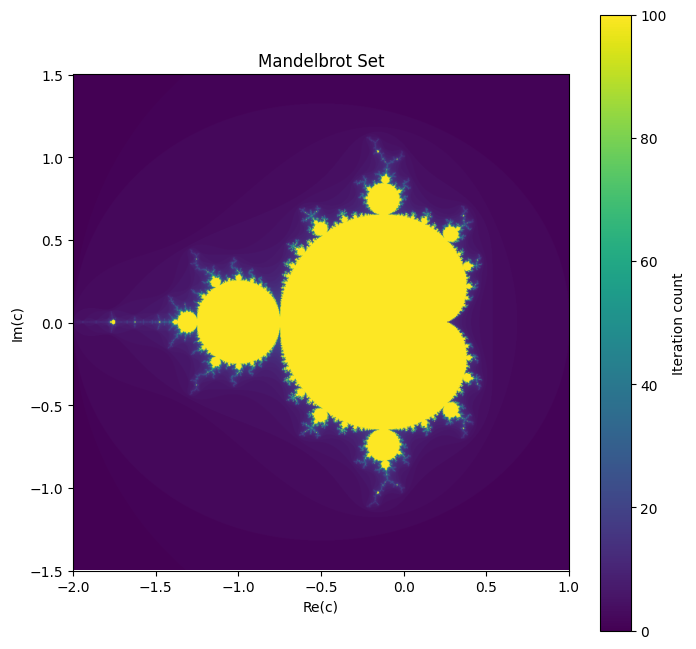

886 ms ± 57.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define region: 𝑥 ∈ [−2,1],  𝑦 ∈[−1.5,1.5]
# Typical: 𝑚𝑎𝑥_𝑖𝑡𝑒𝑟 =100, resolution: 1024×1024 or large
xmin, xmax = -2, 1
ymin, ymax = -1.5, 1.5
width, height = 1024, 1024
max_iter = 100

# 2. Create grid of complex numbers 𝑐 over this region
x_values = np.linspace(xmin, xmax, width)
y_values = np.linspace(ymin, ymax, height)

# empty array for unit storage
iterations = np.zeros((height, width), dtype=int)

def mandlebrot_vectorized(x_values, y_values, iterations, plot = False):

    # 3. For each point c in grid (perform operation on each element in array):
    # note to self: 1j is imaginary unit in python
    c = x_values[None, :] + 1j * y_values[:, None]
    
    # > Initialize 𝑧0 = 0 (for all points) (complex256 to prevent overflow of z)
    z = np.zeros_like(c)
    
    # mask to keep track on updated indexes
    mask = np.ones(c.shape, dtype=bool)
    
    # > For 𝑛=0 to 𝑚𝑎𝑥_𝑖𝑡𝑒𝑟:
    for n in range(max_iter):
        
        # > Compute 𝑧𝑛+1 =𝑧𝑛2 +𝑐
        z[mask] = z[mask]**2 + c[mask]
        
        # > If 𝑧𝑛+1 >2: Point escapes! Store 𝑛 
        escaped = np.abs(z) > 2
        newly_escaped = escaped & mask
        iterations[newly_escaped] = n
        mask[newly_escaped] = False
        
    # > If loop completes: Point is in set, store 𝑚𝑎𝑥_𝑖𝑡𝑒𝑟
    iterations[mask] = max_iter
    
    # 5. Visualize with colormap
    if plot:
        plt.figure(figsize=(8, 8))
        plt.imshow(iterations, extent=[xmin, xmax, ymin, ymax], origin='lower')
        plt.colorbar(label="Iteration count")
        plt.title("Mandelbrot Set")
        plt.xlabel("Re(c)")
        plt.ylabel("Im(c)")
        plt.show()
    
    # 4. Return 2D array of iteration counts
    return iterations

mandlebrot_vectorized(x_values, y_values, iterations, True)
        
timeit_vectorized = %timeit -o mandlebrot_vectorized(x_values, y_values, iterations)

using Numba for Just in Time compilation, testing both functions with this:

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

# 1. Define region: 𝑥 ∈ [−2,1],  𝑦 ∈[−1.5,1.5]
# Typical: 𝑚𝑎𝑥_𝑖𝑡𝑒𝑟 =100, resolution: 1024×1024 or large
xmin, xmax = -2, 1
ymin, ymax = -1.5, 1.5
width, height = 1024, 1024
max_iter = 100

# 2. Create grid of complex numbers 𝑐 over this region
x_values = np.linspace(xmin, xmax, width)
y_values = np.linspace(ymin, ymax, height)

# empty array for unit storage
iterations = np.zeros((height, width), dtype=int)

@njit
def mandlebrot_for_loop_njit(x_values, y_values, iterations, plot = False):
    height, width = iterations.shape
    for i in range(height):
        for j in range(width):
            
            # 3. For each point c in grid:
            # note to self: 1j is imaginary unit in python
            c = x_values[j] + 1j * y_values[i]
            
            # > Initialize 𝑧0 =0
            z = 0
            
            # > For 𝑛=0 to 𝑚𝑎𝑥_𝑖𝑡𝑒𝑟:
            for n in range(max_iter):
                
                # > Compute 𝑧𝑛+1 =𝑧𝑛2 +𝑐
                z = z**2 + c
                
                # > If 𝑧𝑛+1 >2: Point escapes! Store 𝑛, break to next point
                if abs(z) > 2:
                    iterations[i, j] = n
                    break
            else:
                # > If loop completes: Point is in set, store 𝑚𝑎𝑥_𝑖𝑡𝑒𝑟
                iterations[i, j] = max_iter
                
    # 5. Visualize with colormap
    # if plot:
    #    plt.figure(figsize=(8, 8))
    #    plt.imshow(iterations, extent=[xmin, xmax, ymin, ymax], origin='lower')
    #    plt.colorbar(label="Iteration count")
    #    plt.title("Mandelbrot Set")
    #    plt.xlabel("Re(c)")
    #    plt.ylabel("Im(c)")
    #    plt.show()
    
    # 4. Return 2D array of iteration counts
    return iterations

timeit_njit = %timeit -o mandlebrot_for_loop(x_values, y_values, iterations)

7.78 s ± 275 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Comparison of solutions for different scales:

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

# 1. Define region: 𝑥 ∈ [−2,1],  𝑦 ∈[−1.5,1.5]
# Typical: 𝑚𝑎𝑥_𝑖𝑡𝑒𝑟 =100, resolution: 1024×1024 or large
xmin, xmax = -2, 1
ymin, ymax = -1.5, 1.5
width, height = 1024, 1024
max_iter = 100

# 2. Create grid of complex numbers 𝑐 over this region
x_values = np.linspace(xmin, xmax, width)
y_values = np.linspace(ymin, ymax, height)

# empty array for unit storage
iterations = np.zeros((height, width), dtype=int)

print("1024x1024, max iterations: 100")
naive_1024 = %timeit -o mandlebrot_for_loop(x_values, y_values, iterations)
vectorized_1024 = %timeit -o mandlebrot_vectorized(x_values, y_values, iterations)
njit_1024= %timeit -o mandlebrot_for_loop_njit(x_values, y_values, iterations)

# bigger scales:
width, height = 1024*2, 1024*2

x_values = np.linspace(xmin, xmax, width)
y_values = np.linspace(ymin, ymax, height)
iterations = np.zeros((height, width), dtype=int)

print("2048x2048, max iterations: 100")
naive_2048 = %timeit -o mandlebrot_for_loop(x_values, y_values, iterations)
vectorized_2048 = %timeit -o mandlebrot_vectorized(x_values, y_values, iterations)
njit_2048 = %timeit -o mandlebrot_for_loop_njit(x_values, y_values, iterations)

# bigger scales:
width, height = 1024*4, 1024*4

x_values = np.linspace(xmin, xmax, width)
y_values = np.linspace(ymin, ymax, height)
iterations = np.zeros((height, width), dtype=int)

print("4096x4096, max iterations: 100")
naive_4096 = %timeit -o mandlebrot_for_loop(x_values, y_values, iterations)
vectorized_4096 = %timeit -o mandlebrot_vectorized(x_values, y_values, iterations)
njit_4096 = %timeit -o mandlebrot_for_loop_njit(x_values, y_values, iterations)

# bigger scales:
width, height = 1024*8, 1024*8

x_values = np.linspace(xmin, xmax, width)
y_values = np.linspace(ymin, ymax, height)
iterations = np.zeros((height, width), dtype=int)

print("8192x8192, max iterations: 100")
naive_8192 = %timeit -o mandlebrot_for_loop(x_values, y_values, iterations)
vectorized_8192 = %timeit -o mandlebrot_vectorized(x_values, y_values, iterations)
njit_8192 = %timeit -o mandlebrot_for_loop_njit(x_values, y_values, iterations)

# saving results locally (csv)
import csv

results = {
    "naive_1024": naive_1024,
    "vectorized_1024": vectorized_1024,
    "njit_1024": njit_1024,
    "naive_2048": naive_2048,
    "vectorized_2048": vectorized_2048,
    "njit_2048": njit_2048,
    "naive_4096": naive_4096,
    "vectorized_4096": vectorized_4096,
    "njit_4096": njit_4096,
    "naive_8192": naive_8192,
    "vectorized_8192": vectorized_8192,
    "njit_8192": njit_8192
}

# collect all attribute names dynamically
all_attrs = set()
for obj in results.values():
    all_attrs.update(vars(obj).keys())

all_attrs = sorted(all_attrs)

with open("benchmarks.csv", "w", newline="") as f:
    writer = csv.writer(f)

    # header
    writer.writerow(["test_name"] + all_attrs)

    # rows
    for name, obj in results.items():
        data = vars(obj)
        row = [name] + [data.get(attr, "") for attr in all_attrs]
        writer.writerow(row)

1024x1024, max iterations: 100
6.64 s ± 300 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
695 ms ± 33.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
236 ms ± 21.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2048x2048, max iterations: 100
27.5 s ± 697 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
3.01 s ± 37.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
827 ms ± 8.53 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
4096x4096, max iterations: 100
1min 48s ± 3.8 s per loop (mean ± std. dev. of 7 runs, 1 loop each)
12 s ± 308 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
3.13 s ± 27.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
8192x8192, max iterations: 100
7min 7s ± 21.3 s per loop (mean ± std. dev. of 7 runs, 1 loop each)
49.8 s ± 4.23 s per loop (mean ± std. dev. of 7 runs, 1 loop each)
13.3 s ± 88.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Plot of comparison of runs:

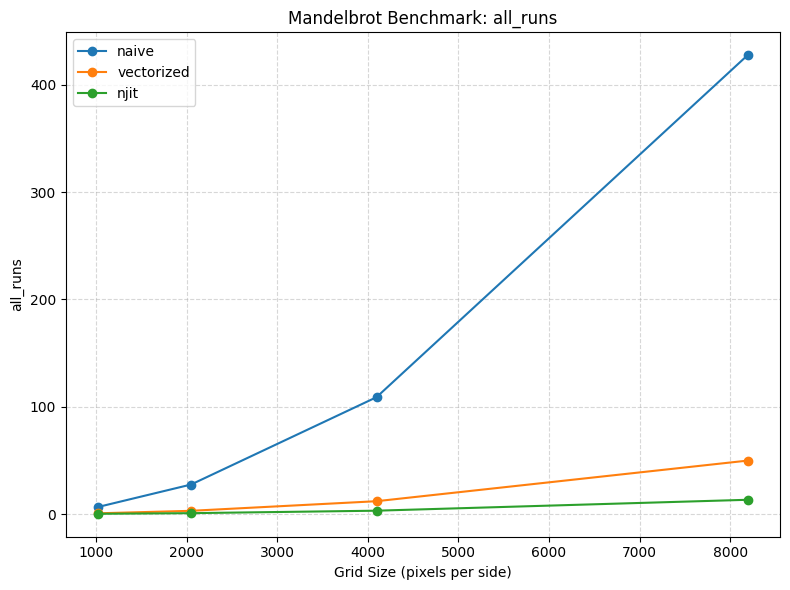

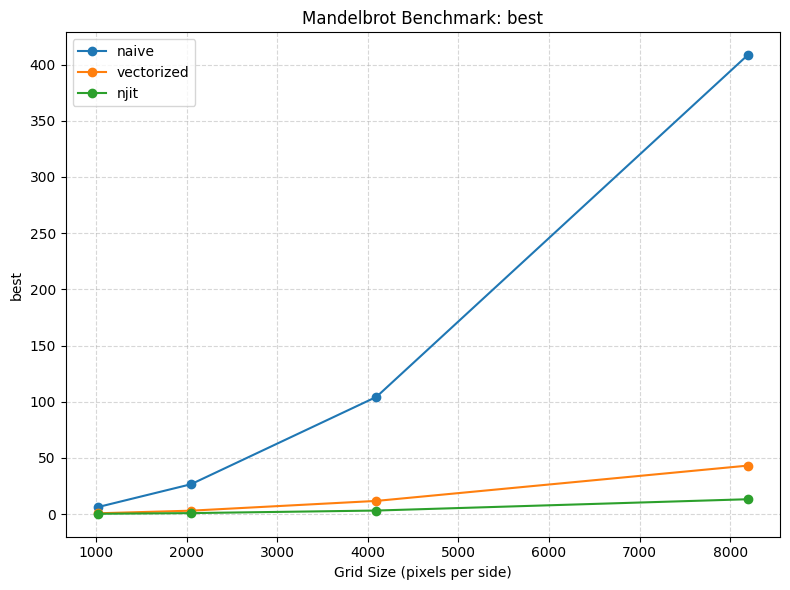

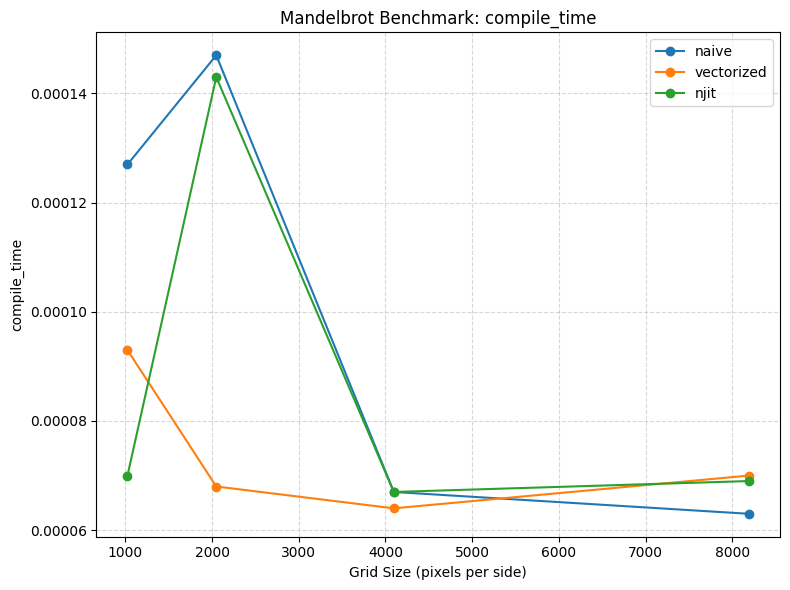

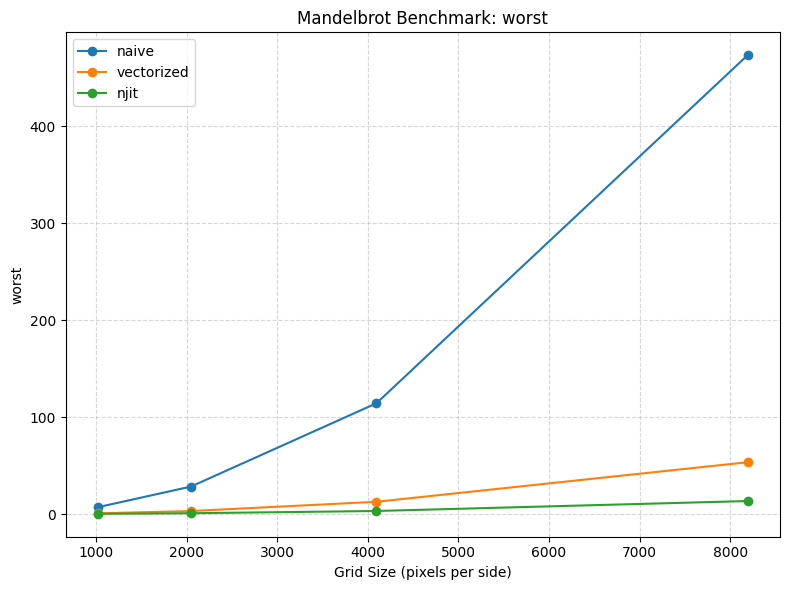

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV
csv_file = "benchmarks.csv"
df = pd.read_csv(csv_file)

# Split test_name into method and size
df[['method','size']] = df['test_name'].str.rsplit('_', n=1, expand=True)
df['size'] = df['size'].astype(int)

# Convert 'all_runs' strings to average float and save in df under 'all_runs'
def parse_all_runs(s):
    s = s.strip()[1:-1]          # remove [ and ]
    return sum(map(float, s.split(','))) / len(s.split(','))

if 'all_runs' in df.columns:
    df['all_runs'] = df['all_runs'].apply(parse_all_runs)

# Identify numeric columns to plot
numeric_cols = df.select_dtypes(include='number').columns.tolist()
# Remove 'size' if included
numeric_cols = [col for col in numeric_cols if col not in ['size']]

#excluded tests results, i exclude these because they do not contain valueable information
excludes = ['_precision', 'loops', 'repeat']

# Create a plot for each numeric attribute
for col in numeric_cols:
    #skip
    if col in excludes:
            continue
    plt.figure(figsize=(8,6))
    for method in df['method'].unique():
        method_df = df[df['method'] == method].sort_values('size')
        y = method_df[col].astype(float)  # ensure numeric
        x = method_df['size']
        plt.plot(x, y, marker='o', label=method)
    plt.xlabel("Grid Size (pixels per side)")
    plt.ylabel(col)
    plt.title(f"Mandelbrot Benchmark: {col}")
    plt.grid(True, ls="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()